Prediction for 6 (should be ~13): [13.05049755]


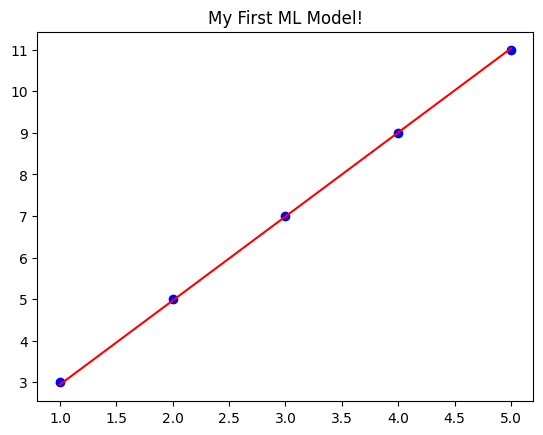

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from my_ml_package.linear_regression import LinearRegression

# 1. Create tiny fake data: y = 2x + 1
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([3, 5, 7, 9, 11])

# 2. Use YOUR custom package
model = LinearRegression(lr=0.01, epochs=1000)
model.fit(X, y)

# 3. Predict for a new number (like 6)
prediction = model.predict(np.array([[6]]))
print(f"Prediction for 6 (should be ~13): {prediction}")

# 4. Plot it to see the "Best Fit" line
plt.scatter(X, y, color='blue')
plt.plot(X, model.predict(X), color='red')
plt.title("My First ML Model!")
plt.show()

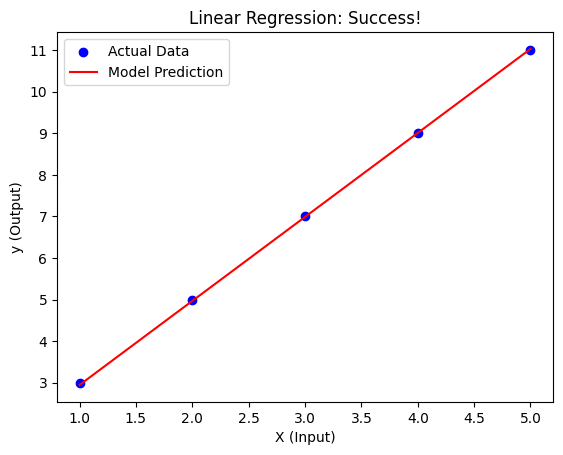

In [3]:
import matplotlib.pyplot as plt

# 1. Ask the model to predict for our training data
predictions = model.predict(X)

# 2. Plot the real data (Blue dots) vs the Model's guess (Red line)
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, predictions, color='red', label='Model Prediction')
plt.xlabel("X (Input)")
plt.ylabel("y (Output)")
plt.legend()
plt.title("Linear Regression: Success!")
plt.show()

In [1]:
import numpy as np
from my_ml_package.linear_regression import LinearRegression

print("✅ The package is live!")

# Create tiny test data
X = np.array([[1], [2], [3]])
y = np.array([2, 4, 6])

model = LinearRegression()
model.fit(X, y)
print("✅ The model just trained!")

✅ The package is live!
✅ The model just trained!


In [4]:
import pandas as pd

df = pd.read_csv('../data/emissions.csv')

df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14925 entries, 0 to 14924
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         14925 non-null  object 
 1   year            14925 non-null  int64  
 2   iso_code        14925 non-null  object 
 3   total_ghg       14475 non-null  float64
 4   ghg_per_capita  14475 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 583.1+ KB


In [7]:
df = df.dropna()
# convert categorical columns into numbers
df_encoded = pd.get_dummies(df, columns=['country', 'iso_code'], drop_first=True)
# define x and y
X = df_encoded.drop(['total_ghg', 'ghg_per_capita'], axis=1)
y = df_encoded['total_ghg']

# train and test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 6.7 MB/s  0:00:01m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 7.0 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
preds = model.predict(X_test)
from sklearn.metrics import mean_squared_error

print(mean_squared_error(y_test, preds))

69386.72391483364


In [10]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("MSE:", mse)
print("R²:", r2)

MSE: 69386.72391483364
R²: 0.8202887896906299


In [11]:
print("Model Performance Summary")
print("------------------------")
print("R² Score:", r2)
print("MSE:", mse)

Model Performance Summary
------------------------
R² Score: 0.8202887896906299
MSE: 69386.72391483364


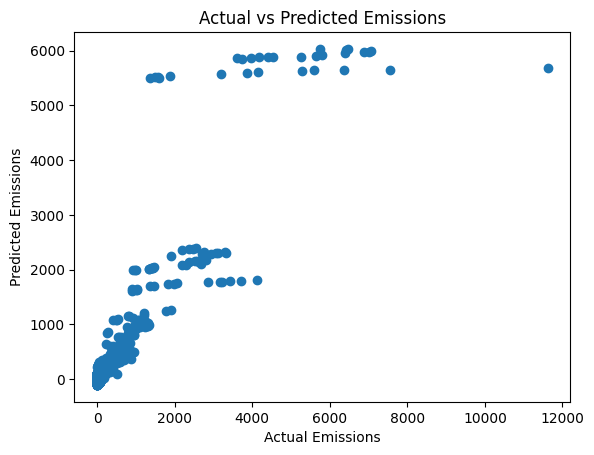

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test, preds)
plt.xlabel("Actual Emissions")
plt.ylabel("Predicted Emissions")
plt.title("Actual vs Predicted Emissions")
plt.show()

# Unsupervised learning, Kmeans


In [17]:
import os
import sys

# 1. Check if the path actually exists
src_path = os.path.abspath('../src')
print(f"Checking path: {src_path}")
print(f"Path exists? {os.path.exists(src_path)}")

# 2. Look for the __init__.py files specifically
init_1 = os.path.join(src_path, 'my_ml_package/__init__.py')
init_2 = os.path.join(src_path, 'my_ml_package/unsupervised/__init__.py')

print(f"Main __init__ found? {os.path.exists(init_1)}")
print(f"Unsupervised __init__ found? {os.path.exists(init_2)}")

# 3. Check the contents of the unsupervised folder
unsupervised_path = os.path.join(src_path, 'my_ml_package/unsupervised')
if os.path.exists(unsupervised_path):
    print(f"Contents of unsupervised: {os.listdir(unsupervised_path)}")

Checking path: /Users/irisli/Desktop/final_project/src
Path exists? True
Main __init__ found? True
Unsupervised __init__ found? True
Contents of unsupervised: ['__init__.py', 'kmeans.py']


In [1]:
import sys
import os

# This adds the 'src' directory to the notebook's search path
sys.path.append(os.path.abspath('../src'))

# NOW your imports will work
from my_ml_package.unsupervised.kmeans import KMeans


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from my_ml_package.unsupervised.kmeans import KMeans

# 1. Load data
df = pd.read_csv('../data/emissions.csv')

# 2. Clean Data: Remove NaNs and filter for the most recent year
# (Clustering across all years makes the plot messy; 2021/2022 gives a better snapshot)
latest_year = df['year'].max()
df_recent = df[df['year'] == latest_year].dropna(subset=['total_ghg', 'ghg_per_capita'])

# 3. Prepare Features
# We use log-scaling or standard scaling because total_ghg is massive
X = df_recent[['total_ghg', 'ghg_per_capita']].values
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)

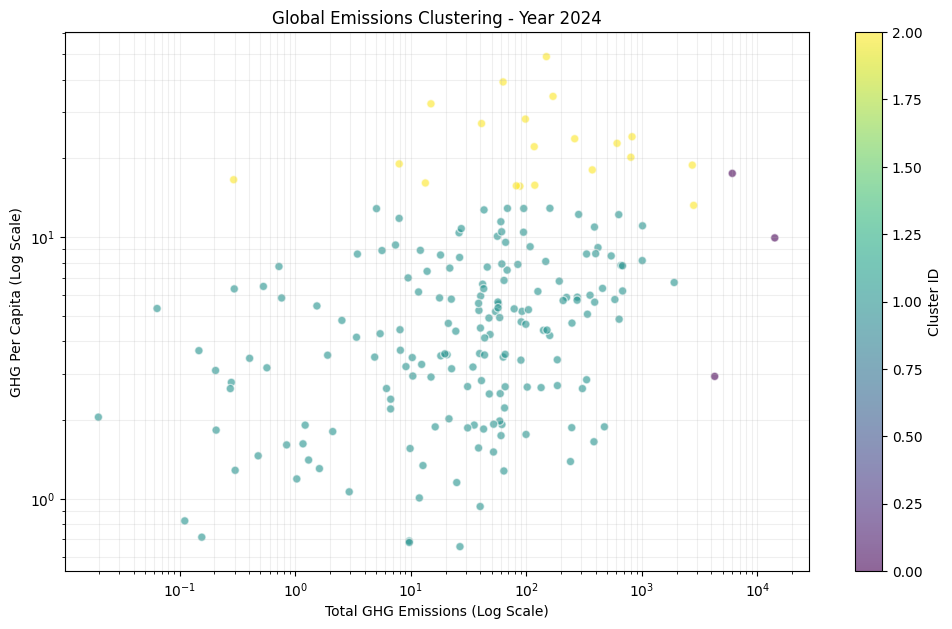

In [2]:
# running the model and visualizing
# 4. Initialize and Fit
# k=3 is a good start: "Small Emitters", "High Per-Capita", and "Heavy Totals"
model = KMeans(k=3)
model.fit(X_scaled)
df_recent['Cluster'] = model.predict(X_scaled)

# 5. Visualization
plt.figure(figsize=(12, 7))
scatter = plt.scatter(df_recent['total_ghg'], df_recent['ghg_per_capita'], 
            c=df_recent['Cluster'], cmap='viridis', alpha=0.6, edgecolors='w')

plt.xscale('log') # Log scale helps see the distribution better
plt.yscale('log')
plt.xlabel('Total GHG Emissions (Log Scale)')
plt.ylabel('GHG Per Capita (Log Scale)')
plt.title(f'Global Emissions Clustering - Year {latest_year}')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

The Yellow Cluster (High Per-Capita): Notice these points are at the very top of the graph. These are likely smaller, wealthy nations or oil-producing states that have extremely high emissions per person, even if their total footprint isn't the largest.

The Purple Cluster (The "Giants"): See those few points way over on the far right? Those are the countries with massive Total GHG emissions (the heavy hitters like China, the US, or India). Your model correctly identified them as their own distinct category because they are outliers in terms of volume.

The Teal Cluster (The Global Average): This is the main body of countries. They have a standard relationship between population/industry and their emissions.

In [3]:
#insight table
# Calculate the average values for each cluster to describe them
analysis = df_recent.groupby('Cluster')[['total_ghg', 'ghg_per_capita']].mean()
print("Cluster Profiles (Averages):")
print(analysis)

Cluster Profiles (Averages):
           total_ghg  ghg_per_capita
Cluster                             
0        8141.241862       10.134669
1         121.306800        4.961388
2         468.305099       23.632226
